In [40]:
# System Parameter
import sys
# Multidimensional Array
import numpy as np
# Manipulation and Data Analysis
import pandas as pd
# Advanced Mathematical Functions
import scipy as sp
from scipy import stats
# Visualization
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
# Feature Engineering and Machine Learning
import sklearn
from sklearn.preprocessing import StandardScaler 
from sklearn.decomposition import PCA

# Summarize software Libraries used
print('Libraries used in this project')
print(f'Python {sys.version}')
print(f'Numpy {np.__version__}')
print(f'Pandas {pd.__version__}')
print(f'Scipy {sp.__version__}')
print(f'Matplotlib {matplotlib.__version__}')
print(f'Seaborn {sns.__version__}')
print(f'Scikit-learn {sklearn.__version__}')

Libraries used in this project
Python 3.14.3 (main, Feb  3 2026, 15:32:20) [GCC 12.3.0]
Numpy 2.4.2
Pandas 3.0.1
Scipy 1.17.0
Matplotlib 3.10.8
Seaborn 0.13.2
Scikit-learn 1.8.0


# Loading Data

In [23]:
user_data = pd.read_pickle('users_data.pickle')
print(user_data.head())
print(user_data.shape)
print(f"Unique users: {len(np.unique(user_data.user_id))}")

                                user_id  number_transactions  \
0  9231c446-cb16-4b2b-a7f7-ddfc8b25aaf6                  3.0   
1  bb92765a-08de-4963-b432-496524b39157                  NaN   
2  573de577-49ef-42b9-83da-d3cfb817b5c1                  2.0   
3  d6b66b9d-7c8f-4257-a682-e136f640b7e3                  NaN   
4  fade0b20-7594-4d9a-84cd-c02f79b1b526                  1.0   

   total_amount_usd  age           job  marital  education  default  housing  \
0            2143.0   58    management  married   tertiary    False     True   
1               NaN   44    technician   single  secondary    False     True   
2               2.0   33  entrepreneur  married  secondary    False     True   
3               NaN   47   blue-collar  married       None    False     True   
4               1.0   33          None   single       None    False    False   

    loan contact  duration  campaign  pdays  previous poutcome  term_deposit  \
0  False    None       261         1     -1         0 

# Data Exploration

In [38]:
user_data.info()
# Fixed grouping syntax
print(user_data.columns.to_series().groupby(user_data.dtypes).groups)

<class 'pandas.DataFrame'>
Index: 45209 entries, 0 to 45215
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   user_id              45209 non-null  object        
 1   number_transactions  35210 non-null  float64       
 2   total_amount_usd     35210 non-null  float64       
 3   age                  45209 non-null  int64         
 4   job                  44921 non-null  object        
 5   marital              45209 non-null  object        
 6   education            43352 non-null  object        
 7   default              45209 non-null  bool          
 8   housing              45209 non-null  bool          
 9   loan                 45209 non-null  bool          
 10  contact              32191 non-null  object        
 11  duration             45209 non-null  int64         
 12  campaign             45209 non-null  int64         
 13  pdays                45209 non-null  int64     

# Correlation and Statistics

In [25]:
correlation_matrix = user_data.corr(numeric_only=True).abs()
print(correlation_matrix)
print(user_data.describe())
print(user_data.drop(['user_id'], axis=1).mode())

                     number_transactions  total_amount_usd       age  \
number_transactions             1.000000          0.163409  0.008813   
total_amount_usd                0.163409          1.000000  0.095839   
age                             0.008813          0.095839  1.000000   
default                         0.138838          0.065390  0.017875   
housing                         0.030429          0.066857  0.185552   
loan                            0.075319          0.084526  0.015641   
duration                        0.017220          0.022586  0.004645   
campaign                        0.026431          0.017274  0.004767   
pdays                           0.030751          0.006435  0.023745   
previous                        0.023046          0.016952  0.001297   
term_deposit                    0.053390          0.050785  0.025168   

                      default   housing      loan  duration  campaign  \
number_transactions  0.138838  0.030429  0.075319  0.017220  0

# Skewness and Kurtosis (added numeric_only for newer pandas versions)

In [26]:
print(user_data.skew(numeric_only=True))
print(user_data.kurt(numeric_only=True))

number_transactions     2.704543
total_amount_usd        8.596128
age                     0.684861
default                 7.245206
housing                -0.224686
loan                    1.852545
duration                3.144556
campaign                4.898555
pdays                   2.615635
previous               41.845672
term_deposit            2.383403
dtype: float64
number_transactions       6.659034
total_amount_usd        150.790967
age                       0.319760
default                  50.495241
housing                  -1.949602
loan                      1.431987
duration                 18.155941
campaign                 39.248145
pdays                     6.934713
previous               4506.684640
term_deposit              3.680770
dtype: float64


# Visualization

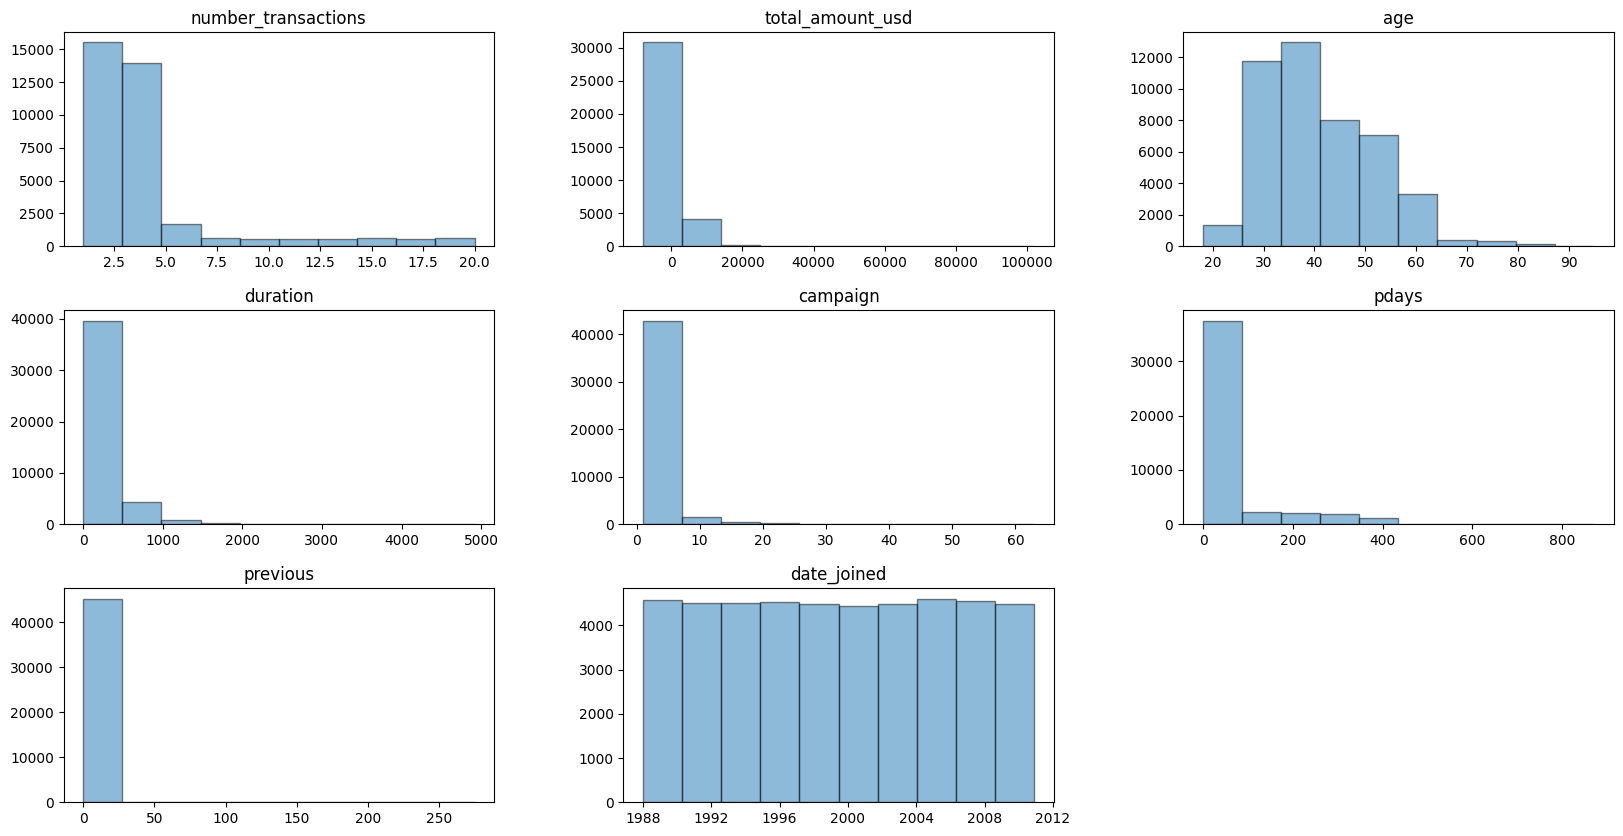

In [27]:
user_data_for_hist = user_data.select_dtypes(exclude=['bool'])
user_data_for_hist.hist(figsize=(20,10), alpha=0.5, edgecolor='black', grid=False)
plt.show()

# Handling Missing Values

In [28]:
print(user_data.isnull().sum())
percent_missing = user_data.isnull().mean()

user_id                    0
number_transactions     9999
total_amount_usd        9999
age                        0
job                      288
marital                    0
education               1857
default                    0
housing                    0
loan                       0
contact                13018
duration                   0
campaign                   0
pdays                      0
previous                   0
poutcome               36957
term_deposit               0
date_joined               30
device                    94
dtype: int64


# Fixed function name and internal logic

In [29]:
def get_missing_value_pct_df(data):
    pct_missing = data.isnull().mean()
    # Fixed naming and quotes
    missing_df = pd.DataFrame(pct_missing).reset_index()
    missing_df.columns = ['column_name', 'percent_missing']
    
    # Multiply by 100 and round
    missing_df['percent_missing'] = missing_df['percent_missing'].apply(lambda x: round(x * 100, 2))
    missing_df = missing_df.sort_values(by='percent_missing', ascending=False)
    return missing_df

missing_value_df = get_missing_value_pct_df(user_data)
print(missing_value_df)

            column_name  percent_missing
15             poutcome            81.75
10              contact            28.80
1   number_transactions            22.12
2      total_amount_usd            22.12
6             education             4.11
4                   job             0.64
18               device             0.21
17          date_joined             0.07
0               user_id             0.00
5               marital             0.00
3                   age             0.00
9                  loan             0.00
8               housing             0.00
7               default             0.00
11             duration             0.00
14             previous             0.00
13                pdays             0.00
12             campaign             0.00
16         term_deposit             0.00


# Threshold logic

In [30]:
threshold = 80
cols_to_drop = list(missing_value_df[missing_value_df['percent_missing'] > threshold]['column_name'])
print(f'Number of features to drop: {len(cols_to_drop)}')
print(f'Features with missing values greater than {threshold}%: {cols_to_drop}')

user_data_cleaned = user_data.drop(columns=cols_to_drop)

Number of features to drop: 1
Features with missing values greater than 80%: ['poutcome']


# Re-check missing after drop

In [32]:
missing_value_df_cleaned = get_missing_value_pct_df(user_data_cleaned)
missing_column = list(missing_value_df_cleaned[missing_value_df_cleaned['percent_missing'] > 0]['column_name'])

# Numerical Imputation

In [33]:
dtypes = ['int64', 'float64']
numerical_columns = list(user_data_cleaned.select_dtypes(include=dtypes).columns)
missing_num_cols = list(set(numerical_columns).intersection(missing_column))
print(f'Numerical features with missing values: {missing_num_cols}')

Numerical features with missing values: ['number_transactions', 'total_amount_usd']


# Sample user check

In [34]:
if 'total_amount_usd' in user_data_cleaned.columns:
    sample_users = user_data_cleaned[user_data_cleaned['total_amount_usd'].isnull()].sample(1)['user_id']
    
    mean_val = round(user_data_cleaned['total_amount_usd'].mean(), 2)
    # Note: inplace=True is being deprecated in some pandas versions; assignment is safer
    user_data_cleaned['total_amount_usd'] = user_data_cleaned['total_amount_usd'].fillna(mean_val)
    
    # Fill number_transactions with 0
    user_data_cleaned['number_transactions'] = user_data_cleaned['number_transactions'].fillna(0)

# Categorical Imputation

In [35]:
categorical_columns = list(user_data_cleaned.select_dtypes(include=['object']).columns)
missing_cat_cols = list(set(categorical_columns).intersection(missing_column))
print(f'Categorical features with missing values: {missing_cat_cols}')

Categorical features with missing values: ['device', 'job', 'education', 'contact']


# Bulk fill Unknowns

In [36]:
for col in ['job', 'contact', 'device', 'education']:
    if col in user_data_cleaned.columns:
        user_data_cleaned[col] = user_data_cleaned[col].fillna('Unknown')

# Final Verification

In [37]:
print(user_data_cleaned['device'].value_counts())

device
mobile     27504
desktop    12112
tablet      5499
Unknown       94
Name: count, dtype: int64
